In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import scipy

import os

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)


In [3]:
sc.settings.set_figure_params(dpi=120)

In [4]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:356: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


# Variables

In [5]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
!ls {data_object_dir}

all_b2c_cells_filtered_raw.h5ad
all_b2c_cells_raw.h5ad
archive_17Nov2025
epicardium-mixture_b2c_cells_filtered_raw.h5ad
erythrocytes_b2c_cells_filtered_raw.h5ad
scVI
unclassified-mixture_b2c_cells_filtered_raw.h5ad


In [6]:
embedding_basis = 'X_umap_scVI_n-layers-3'

# Read in adata

In [7]:
%%time
adata = sc.read_h5ad(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')
adata

CPU times: user 581 ms, sys: 2.94 s, total: 3.53 s
Wall time: 45.8 s


AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre'
    var: 'gene_ids', 'feature_types', 'genome', 'mt'

In [8]:
adata_unc = sc.read_h5ad(f'{data_object_dir}/unclassified-mixture_b2c_cells_filtered_raw.h5ad',
                         backed='r')
adata_unc

AnnData object with n_obs × n_vars = 56885 × 18085 backed at '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/unclassified-mixture_b2c_cells_filtered_raw.h5ad'
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers

In [9]:
adata_epi = sc.read_h5ad(f'{data_object_dir}/epicardium-mixture_b2c_cells_filtered_raw.h5ad',
                         backed='r')
adata_epi

AnnData object with n_obs × n_vars = 45632 × 18085 backed at '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/epicardium-mixture_b2c_cells_filtered_raw.h5ad'
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3

In [22]:
adata_ery = sc.read_h5ad(f'{data_object_dir}/erythrocytes_b2c_cells_filtered_raw.h5ad',
                         backed='r')
adata_ery

AnnData object with n_obs × n_vars = 6618 × 18085 backed at '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/erythrocytes_b2c_cells_filtered_raw.h5ad'
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_

# Add unclassified_mixture annotations

In [23]:
adata.obs['coarse_grain_pre_2'] = adata.obs['coarse_grain_pre'].copy()
adata.obs['coarse_grain_pre_2'] = adata.obs['coarse_grain_pre_2'].astype('str')
adata.obs.loc[adata_unc.obs_names,'coarse_grain_pre_2'] = adata_unc.obs['coarse_grain_pre'].astype('str').copy()
adata.obs.loc[adata_epi.obs_names,'coarse_grain_pre_2'] = adata_epi.obs['coarse_grain_pre'].astype('str').copy()
adata.obs.loc[adata_ery.obs_names,'coarse_grain_pre_2'] = 'Erythrocytes'
adata.obs['coarse_grain_pre_2'].value_counts()

coarse_grain_pre_2
VentricularCardiomyocytes                      106519
Mesenchymal                                     38029
AtrialCardiomyocytes                            31838
unclassified_mixture                            20361
Erythrocytes                                     6618
unclassified_mixture_vCM-vasculature             4190
unclassified_mixture_aCM-epicardium              2581
unclassified_mixture_vCM-macrophage              2465
LymphaticEndothelialCells                        2169
Endothelium                                      2065
unclassified_mixture_vCM-epicardium              1931
NeuralCells                                      1851
EpicardialCells                                  1408
MyeloidCells                                     1157
EpithelialCells                                   700
Megakaryocytes                                    359
unclassified_mixture_aCM-vasculature              353
unclassified_mixture_Mesenchymal-LEC-Immune       267
unclassif

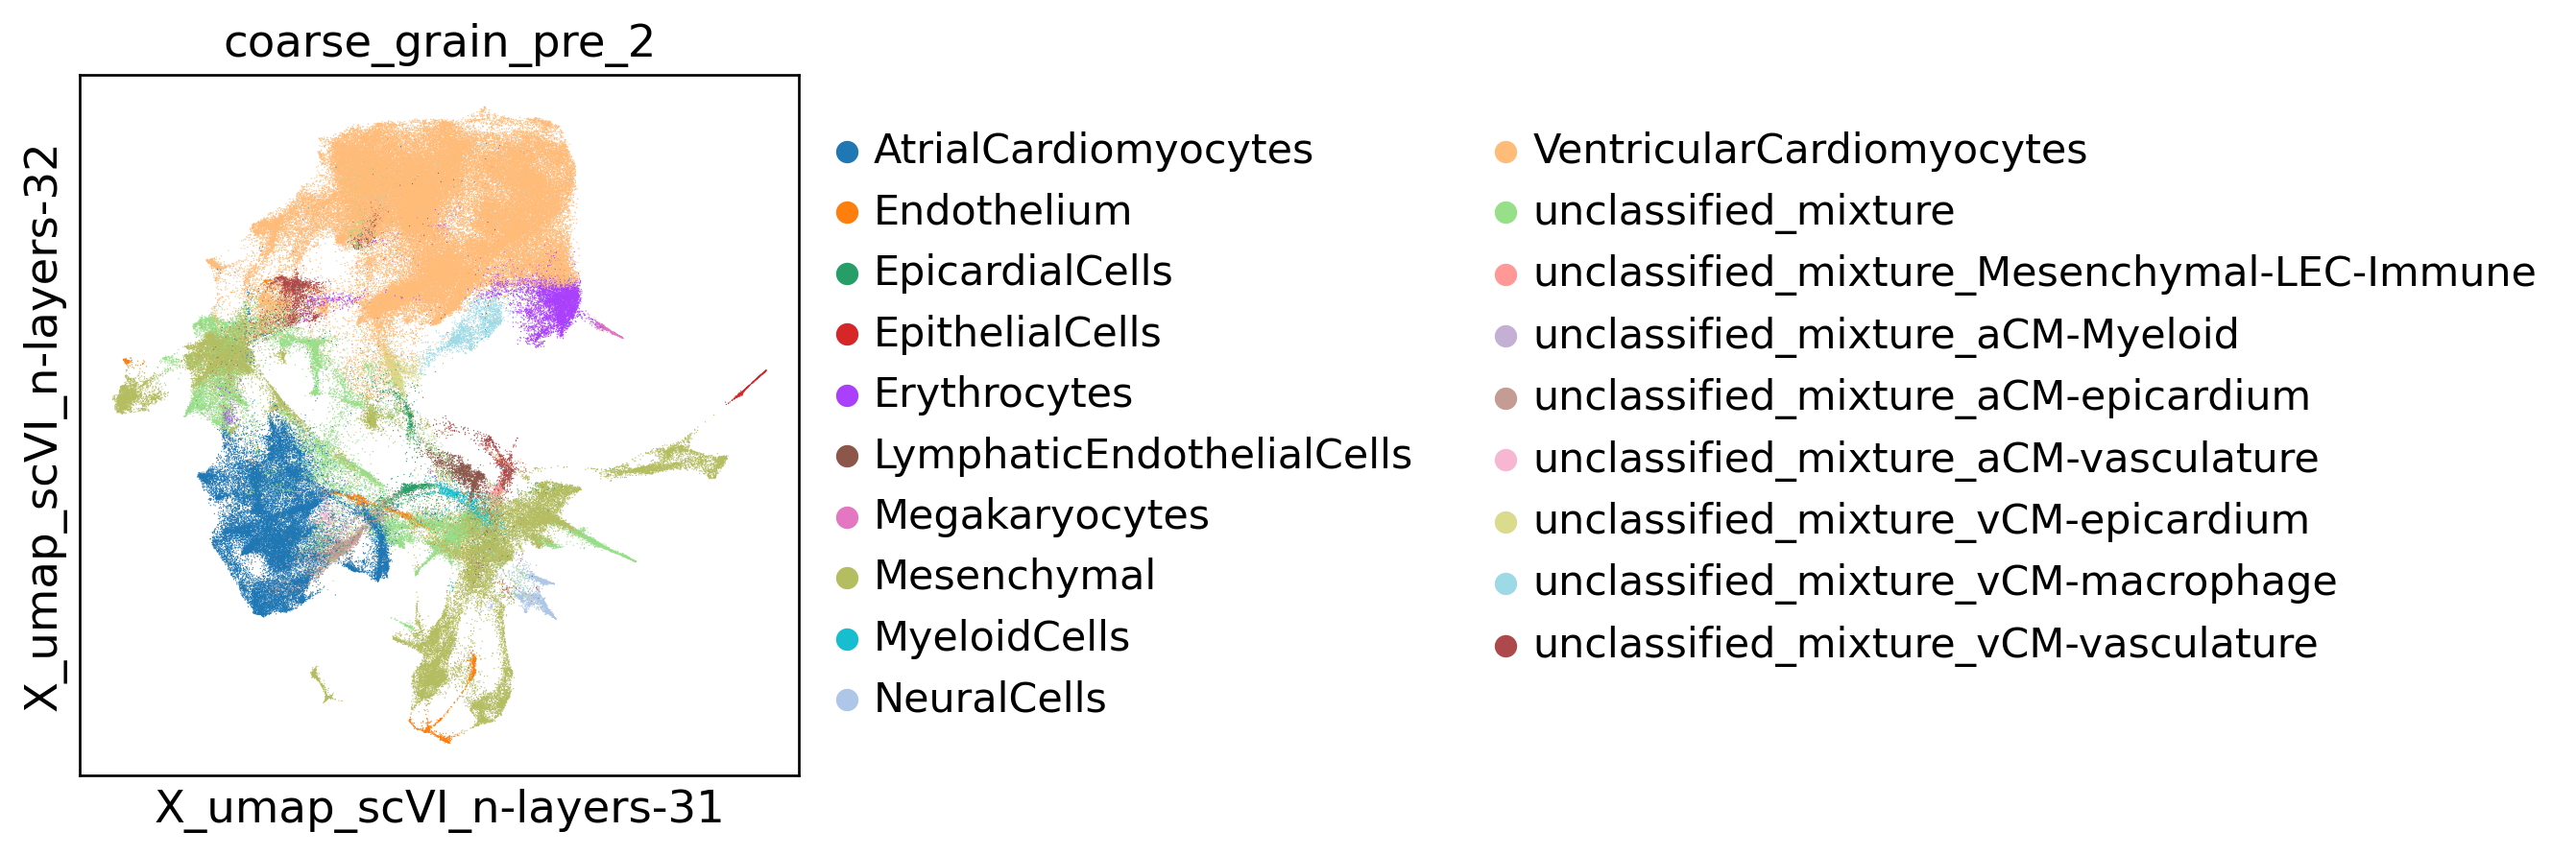

In [24]:
sc.pl.embedding(adata,basis=embedding_basis,
                color='coarse_grain_pre_2')

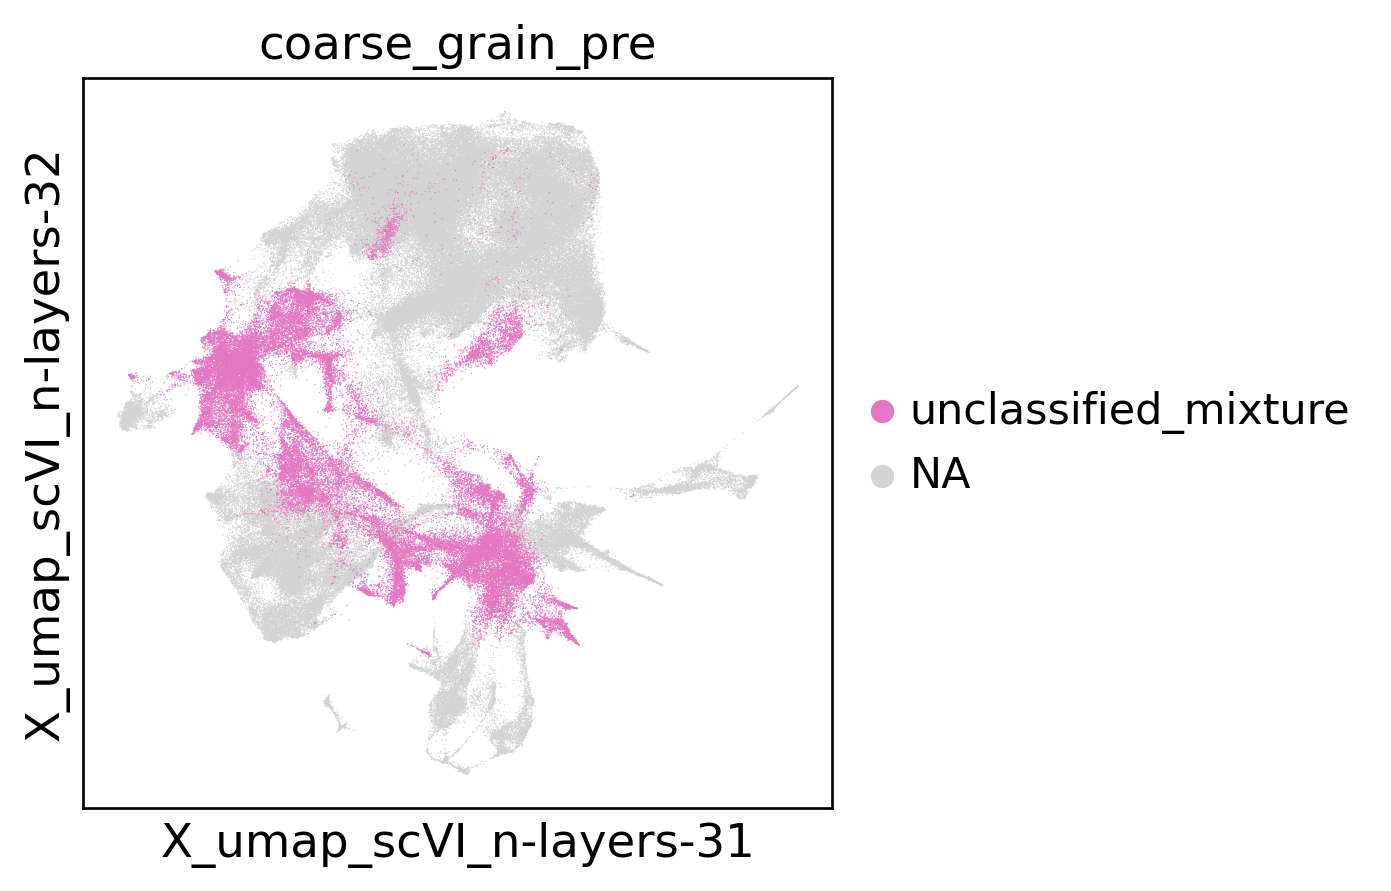

In [25]:
sc.pl.embedding(adata,basis=embedding_basis,
                color='coarse_grain_pre', groups=['unclassified_mixture'])

# Rename some of the cell types

In [26]:
label_mapping = {
    'Endothelium':'EndothelialCells',
    'Mesenchymal':'MesenchymalCells',
}
adata.obs.replace({'coarse_grain_pre_2':label_mapping},inplace=True)
adata.obs['coarse_grain_pre_2'].value_counts()

/tmp/ipykernel_256964/248702623.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({'coarse_grain_pre_2':label_mapping},inplace=True)


coarse_grain_pre_2
VentricularCardiomyocytes                      106519
MesenchymalCells                                38029
AtrialCardiomyocytes                            31838
unclassified_mixture                            20361
Erythrocytes                                     6618
unclassified_mixture_vCM-vasculature             4190
unclassified_mixture_aCM-epicardium              2581
unclassified_mixture_vCM-macrophage              2465
LymphaticEndothelialCells                        2169
EndothelialCells                                 2065
unclassified_mixture_vCM-epicardium              1931
NeuralCells                                      1851
EpicardialCells                                  1408
MyeloidCells                                     1157
EpithelialCells                                   700
Megakaryocytes                                    359
unclassified_mixture_aCM-vasculature              353
unclassified_mixture_Mesenchymal-LEC-Immune       267
unclassif

# Check whether there's a missing cell types

In [14]:
ad = sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/RNA/Feb28ObjectRaw_finegrain_updated.h5ad',
                 backed='r')

In [15]:
set(ad.obs['coarse_grain'])

{'Cardiomyocytes',
 'Endothelium',
 'Epicardium',
 'Leukocytes',
 'Mesenchymal',
 'Neural'}

- Cardiomyocytes --> AtrialCM and VentricularCM in the VisiumHD coarse_grain
- Leukocytes --> only MyeloidCells
- LymphaticEndothelialCells is separated from Endothelium
- Cell types need to be removed: EpithelialCells, Megakaryocytes

In [16]:
set(ad.obs['mid_grain'])

{'AtrialCardiomyocytes',
 'BloodVesselEndothelialCells',
 'CardiacConductionSystem',
 'EndocardialCells',
 'EpicardialCells',
 'Fibroblasts',
 'Glia',
 'LymphaticEndothelialCells',
 'LymphoidCells',
 'MuralCells',
 'MyeloidCells',
 'Neurons',
 'PericardialCells',
 'VentricularCardiomyocytes'}

# Plotting marker gene expressions

In [28]:
adata_lognorm = adata.copy()

sc.pp.filter_genes(adata_lognorm, min_cells=3)
print(adata_lognorm.shape)

sc.pp.normalize_total(adata_lognorm, target_sum=1e4)
sc.pp.log1p(adata_lognorm)
print(adata_lognorm.X.data[:5])

(225097, 18070)
[1.8897898 1.8897898 1.8897898 1.8897898 1.8897898]


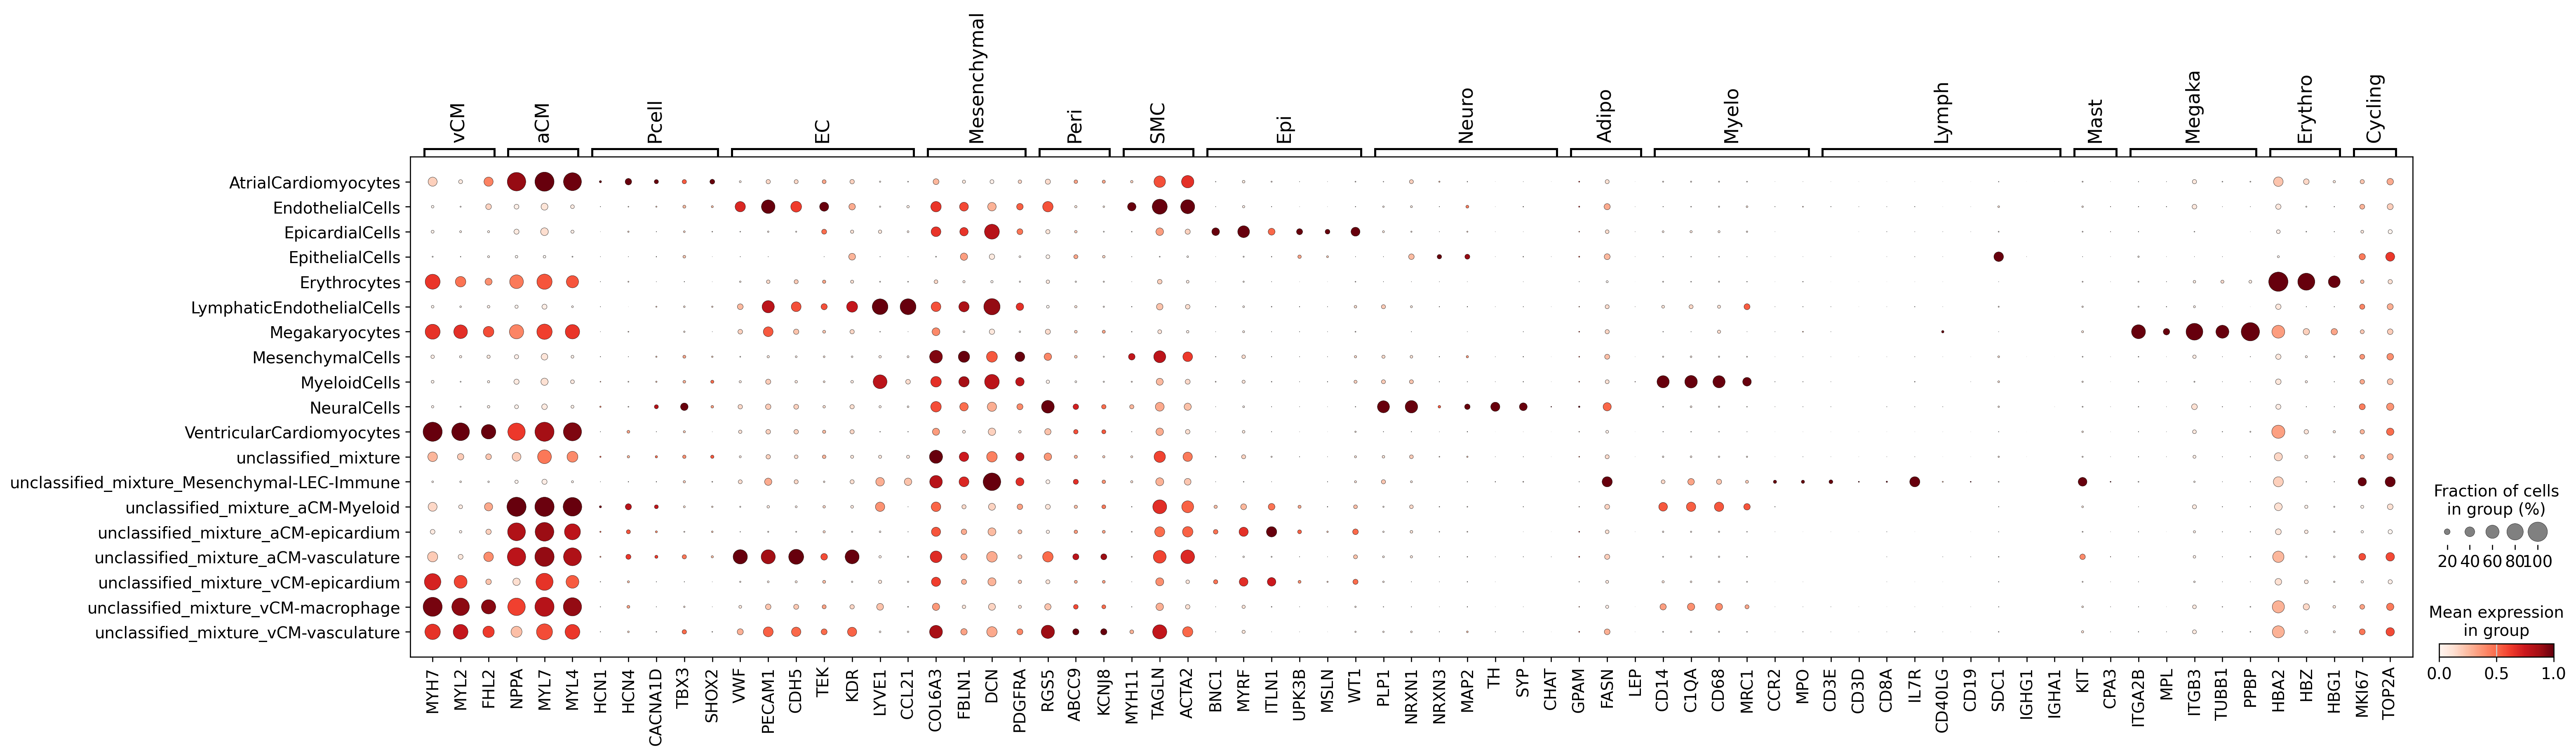

In [29]:
marker_genes_dict = {
    'vCM': ['MYH7', 'MYL2', 'FHL2'],
    'aCM': ['NPPA', 'MYL7', 'MYL4'],
    'Pcell':['HCN1','HCN4','CACNA1D','TBX3','SHOX2'],
    'EC': ['VWF', 'PECAM1', 'CDH5','TEK','KDR','LYVE1','CCL21'],
    'Mesenchymal': ['COL6A3','FBLN1','DCN', 'GCN', 'PDGFRA'],
    'Peri': ['RGS5', 'ABCC9', 'KCNJ8'],
    'SMC': ['MYH11', 'TAGLN', 'ACTA2'],
    'Epi':['BNC1','MYRF','ITLN1','UPK3B','MSLN','WT1'],
    'Neuro': ['PLP1', 'NRXN1', 'NRXN3',"TUBB3","MAP2",'TH','SYP','CHAT'],
    'Adipo': ['GPAM', 'FASN', 'LEP'],
    'Myelo': ['CD14', 'C1QA', 'CD68','MRC1','CCR2','MPO'],
    'Lymph': ['CD3E','CD3D','CD8A','IL7R', 'CD40LG','CD19','SDC1','IGHG1','IGHA1'],
    'Mast': ['KIT', 'CPA3'],
    'Megaka':['ITGA2B','MPL','ITGB3', 'TUBB1', 'PPBP'],
    'Erythro':['HBA2','HBZ','HBG1'],
    'Cycling':['MKI67','TOP2A'],
    # 'Mitochondria':['MT-CO1','MT-CO3','MT-CYB','MT-ATP6']
}

for k, v in marker_genes_dict.items():
    marker_genes_dict[k] = [x for x in v if x in adata_lognorm.var_names]

sc.pl.dotplot(adata_lognorm, 
              marker_genes_dict, 
              groupby='coarse_grain_pre_2',
              dendrogram=False,
              standard_scale="var",
              color_map="Reds",
             # swap_axes=True
             )

In [30]:
set(adata.obs['coarse_grain_pre_2'])

{'AtrialCardiomyocytes',
 'EndothelialCells',
 'EpicardialCells',
 'EpithelialCells',
 'Erythrocytes',
 'LymphaticEndothelialCells',
 'Megakaryocytes',
 'MesenchymalCells',
 'MyeloidCells',
 'NeuralCells',
 'VentricularCardiomyocytes',
 'unclassified_mixture',
 'unclassified_mixture_Mesenchymal-LEC-Immune',
 'unclassified_mixture_aCM-Myeloid',
 'unclassified_mixture_aCM-epicardium',
 'unclassified_mixture_aCM-vasculature',
 'unclassified_mixture_vCM-epicardium',
 'unclassified_mixture_vCM-macrophage',
 'unclassified_mixture_vCM-vasculature'}

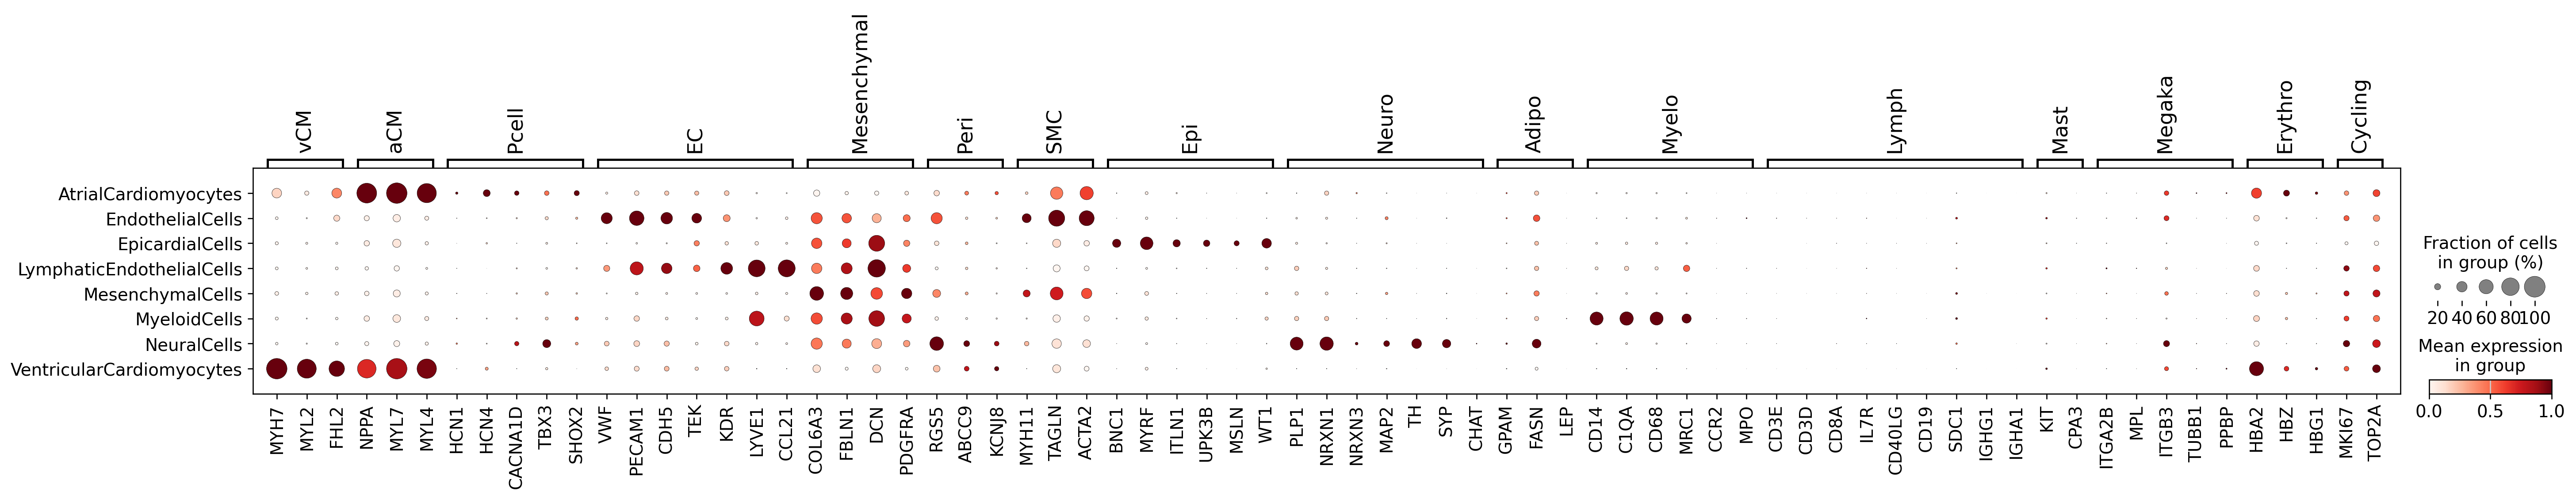

In [32]:
# cleaner dotplot
# by removing not-relevant cell types
ad = adata_lognorm[~adata_lognorm.obs['coarse_grain_pre_2'].isin(['EpithelialCells',
                                                            'Erythrocytes',
                                                            'Megakaryocytes',
                                                            'unclassified_mixture',
                                                             'unclassified_mixture_Mesenchymal-LEC-Immune',
                                                             'unclassified_mixture_aCM-Myeloid',
                                                             'unclassified_mixture_aCM-epicardium',
                                                             'unclassified_mixture_aCM-vasculature',
                                                             'unclassified_mixture_vCM-epicardium',
                                                             'unclassified_mixture_vCM-macrophage',
                                                             'unclassified_mixture_vCM-vasculature'
                                                           ])]

sc.pl.dotplot(ad, 
              marker_genes_dict, 
              groupby='coarse_grain_pre_2',
              dendrogram=False,
              standard_scale="var",
              color_map="Reds",
             # swap_axes=True
             )

# Save

In [33]:
adata.write(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2'
    var: 'gene_ids', 'feature_

# Remove unnecessary cells and save

In [7]:
adata = sc.read_h5ad(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2'
    var: 'gene_ids', 'feature_

In [8]:
adata.obs['coarse_grain_pre_2'].value_counts()

coarse_grain_pre_2
VentricularCardiomyocytes                      106519
MesenchymalCells                                38029
AtrialCardiomyocytes                            31838
unclassified_mixture                            20361
Erythrocytes                                     6618
unclassified_mixture_vCM-vasculature             4190
unclassified_mixture_aCM-epicardium              2581
unclassified_mixture_vCM-macrophage              2465
LymphaticEndothelialCells                        2169
EndothelialCells                                 2065
unclassified_mixture_vCM-epicardium              1931
NeuralCells                                      1851
EpicardialCells                                  1408
MyeloidCells                                     1157
EpithelialCells                                   700
Megakaryocytes                                    359
unclassified_mixture_aCM-vasculature              353
unclassified_mixture_Mesenchymal-LEC-Immune       267
unclassif

In [14]:
# remove
adata_removed = adata[adata.obs['coarse_grain_pre_2'].isin(['Erythrocytes',
                                                    'EpithelialCells',
                                                    'Megakaryocytes'
                                                   ])==False]
# remove latent space and clustering results
# delete previous latent space and clustering results
obs_col = adata_removed.obs.columns.copy()
obs_col = [col for col in obs_col if '_leiden_' in col]
adata_removed.obs.drop(columns=obs_col,inplace=True)

# delete obsm
obsm_keys = list(adata_removed.obsm.keys())
for key in obsm_keys:
    if ('scVI' in key)|('X_umap' in key):
        del adata_removed.obsm[key]
        
# delete uns
uns_keys = list(adata_removed.uns.keys())
for key in uns_keys:
    if 'scVI' in key:
        del adata_removed.uns[key]

adata_removed

AnnData object with n_obs × n_vars = 217420 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_pre_colors', 'donor_colors', 'library_colors', 'neighbors', 'spatial', 'umap'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    obsp: 'connectivities', 'dist

In [15]:
adata_removed.obs['coarse_grain_pre_2'].value_counts()

coarse_grain_pre_2
VentricularCardiomyocytes                      106519
MesenchymalCells                                38029
AtrialCardiomyocytes                            31838
unclassified_mixture                            20361
unclassified_mixture_vCM-vasculature             4190
unclassified_mixture_aCM-epicardium              2581
unclassified_mixture_vCM-macrophage              2465
LymphaticEndothelialCells                        2169
EndothelialCells                                 2065
unclassified_mixture_vCM-epicardium              1931
NeuralCells                                      1851
EpicardialCells                                  1408
MyeloidCells                                     1157
unclassified_mixture_aCM-vasculature              353
unclassified_mixture_Mesenchymal-LEC-Immune       267
unclassified_mixture_aCM-Myeloid                  236
Name: count, dtype: int64

In [16]:
# save
adata_removed.write(f'{data_object_dir}/all_b2c_cells_filtered_celltype-sel.h5ad')

In [17]:
data_object_dir

'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'

In [18]:
adata_removed.X.data[:10]

array([1., 1., 1., 1., 1., 1., 1., 2., 1., 1.], dtype=float32)